In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import random
import json
import os

# Фиксация seed для воспроизводимости
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# 1. Загрузка данных
df = pd.read_csv('data/S12-hw-dataset.csv')

# 2. Sanity check: общая информация
print("Размер датасета:", df.shape)
print("\nПервые 5 строк:")
print(df.head())
print("\nТипы данных:")
print(df.dtypes)

# 3. Преобразование колонки date в datetime и сортировка
# Предполагаем, что колонка называется 'date'
df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

# 4. Диапазон дат
print("\nДиапазон дат:", df['date'].min(), "–", df['date'].max())

# 5. Проверка пропусков
print("\nПропуски в каждой колонке:")
print(df.isnull().sum())



Размер датасета: (4320, 2)

Первые 5 строк:
                  date  target
0  2025-01-01 00:00:00   98.14
1  2025-01-01 01:00:00   98.07
2  2025-01-01 02:00:00  104.70
3  2025-01-01 03:00:00  112.81
4  2025-01-01 04:00:00  112.62

Типы данных:
date       object
target    float64
dtype: object

Диапазон дат: 2025-01-01 00:00:00 – 2025-06-29 23:00:00

Пропуски в каждой колонке:
date      0
target    0
dtype: int64


In [ ]:
class TemporalSplit:
    """
    Воспроизводимое временное разбиение для рядов данных.
    
    Параметры:
    train_ratio : float, default=0.7
        Доля обучающей выборки.
    val_ratio : float, default=0.15
        Доля валидационной выборки.
    test_ratio : float, default=0.15
        Доля тестовой выборки.
    date_col : str, default='date'
        Имя колонки с датой/временем для сортировки.
        Если None, используется текущий порядок индексов.
    """
    
    def __init__(self, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, date_col='date'):
        total = train_ratio + val_ratio + test_ratio
        if not abs(total - 1.0) < 1e-6:
            raise ValueError(f"Сумма долей должна равняться 1, получено {total}")
        self.train_ratio = train_ratio
        self.val_ratio = val_ratio
        self.test_ratio = test_ratio
        self.date_col = date_col
        
    def split(self, df):
        """
        Выполняет разбиение DataFrame на три части.
        
        Возвращает:
        tuple : (train_df, val_df, test_df)
        """
        # Сортировка по времени для гарантии хронологического порядка
        if self.date_col is not None and self.date_col in df.columns:
            df = df.sort_values(by=self.date_col).reset_index(drop=True)
        else:
            # Если колонка не указана или отсутствует, используем текущий порядок
            df = df.reset_index(drop=True)
            
        n = len(df)
        train_end = int(n * self.train_ratio)
        val_end = train_end + int(n * self.val_ratio)
        
        train_df = df.iloc[:train_end]
        val_df = df.iloc[train_end:val_end]
        test_df = df.iloc[val_end:]
        
        return train_df, val_df, test_df

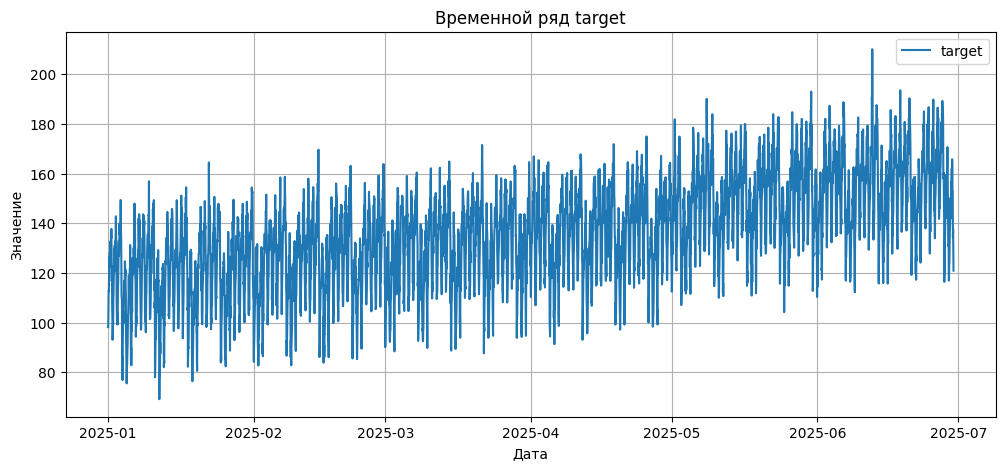


Разбиение: train 3024 строк, validation 648 строк, test 648 строк
Train период: 2025-01-01 00:00:00 – 2025-05-06 23:00:00
Validation период: 2025-05-07 00:00:00 – 2025-06-02 23:00:00
Test период: 2025-06-03 00:00:00 – 2025-06-29 23:00:00


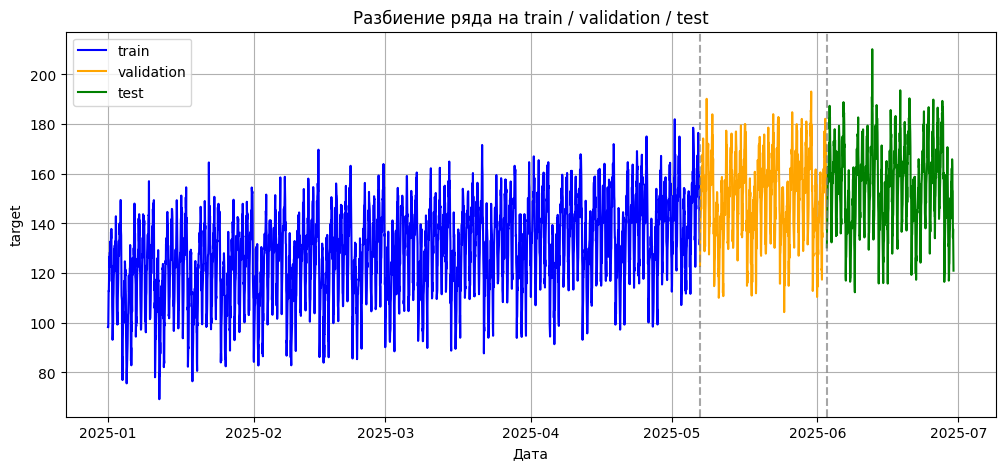

In [ ]:
# 6. Базовый график ряда target
plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['target'], label='target')
plt.title('Временной ряд target')
plt.xlabel('Дата')
plt.ylabel('Значение')
plt.grid(True)
plt.legend()
plt.show()

# В ряде заметен восходящий тренд: средний уровень постепенно увеличивается к концу периода. Также хорошо видна выраженная короткая сезонность с регулярными повторяющимися колебаниями.
# Присутствуют отдельные выбросы — как резкие пики вверх, так и локальные провалы вниз относительно общего уровня. Ряд, вероятно, нестационарен прежде всего по среднему из-за наличия тренда;
# кроме того, к концу периода амплитуда колебаний выглядит немного выше, поэтому возможна и нестационарность по дисперсии.

# Random split нарушает временную структуру данных: перемешивая наблюдения, мы позволяем модели "заглядывать в будущее", так как в обучение попадают данные,
# которые по времени следуют за тестовыми. Это приводит к переоценке качества модели, поскольку в реальном применении прогноз строится только на основе прошлой информации.
# Корректная валидация временных рядов требует сохранения хронологического порядка, чтобы тестовый период всегда находился позже обучающего.

ts = TemporalSplit(train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, date_col='date')

train_df, val_df, test_df = ts.split(df)

print(f"\nРазбиение: train {len(train_df)} строк, validation {len(val_df)} строк, test {len(test_df)} строк")
print(f"Train период: {train_df['date'].min()} – {train_df['date'].max()}")
print(f"Validation период: {val_df['date'].min()} – {val_df['date'].max()}")
print(f"Test период: {test_df['date'].min()} – {test_df['date'].max()}")

plt.figure(figsize=(12, 5))
plt.plot(train_df['date'], train_df['target'], label='train', color='blue')
plt.plot(val_df['date'], val_df['target'], label='validation', color='orange')
plt.plot(test_df['date'], test_df['target'], label='test', color='green')
plt.axvline(x=train_df['date'].iloc[-1], linestyle='--', color='gray', alpha=0.7)
plt.axvline(x=val_df['date'].iloc[-1], linestyle='--', color='gray', alpha=0.7)
plt.title('Разбиение ряда на train / validation / test')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/series_split.png', dpi=150)
plt.show()

В ряде заметен восходящий тренд: средний уровень постепенно увеличивается к концу периода. Также хорошо видна выраженная короткая сезонность с регулярными повторяющимися колебаниями. Присутствуют отдельные выбросы — как резкие пики вверх, так и локальные провалы вниз относительно общего уровня. Ряд, вероятно, нестационарен прежде всего по среднему из-за наличия тренда; кроме того, к концу периода амплитуда колебаний выглядит немного выше, поэтому возможна и нестационарность по дисперсии.

Random split нарушает временную структуру данных: перемешивая наблюдения, мы позволяем модели "заглядывать в будущее", так как в обучение попадают данные, которые по времени следуют за тестовыми. Это приводит к переоценке качества модели, поскольку в реальном применении прогноз строится только на основе прошлой информации. Корректная валидация временных рядов требует сохранения хронологического порядка, чтобы тестовый период всегда находился позже обучающего.

In [4]:
def create_features(df, lags=[1,7,14], rolling_windows=[7]):
    df = df.copy()
    
    for lag in lags:
        df[f'lag_{lag}'] = df['target'].shift(lag)
        
    for win in rolling_windows:
        df[f'rolling_mean_{win}'] = df['target'].rolling(win).mean()
        df[f'rolling_std_{win}'] = df['target'].rolling(win).std()
    
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    return df

def add_features_to_split(base_df, hist_df=None):
    if hist_df is not None:
        combined = pd.concat([hist_df, base_df], axis=0, ignore_index=True)
    else:
        combined = base_df
    combined = create_features(combined)
    return combined.iloc[-len(base_df):].copy()

train_feat = add_features_to_split(train_df)

val_feat = add_features_to_split(val_df, train_df)

test_feat = add_features_to_split(test_df, pd.concat([train_df, val_df], axis=0))

train_feat.dropna(inplace=True)
val_feat.dropna(inplace=True)
test_feat.dropna(inplace=True)

print("Размер после удаления NaN:")
print(f"Train: {len(train_feat)}, Val: {len(val_feat)}, Test: {len(test_feat)}")

Размер после удаления NaN:
Train: 3010, Val: 648, Test: 648


In [ ]:
def scale_features(train_df, val_df, test_df, feature_cols):
    """
    Масштабирует признаки с помощью StandardScaler.
    fit выполняется только на train_df.
    Возвращает масштабированные массивы и обученный scaler.
    """
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_df[feature_cols])
    val_scaled   = scaler.transform(val_df[feature_cols])
    test_scaled  = scaler.transform(test_df[feature_cols])
    return train_scaled, val_scaled, test_scaled, scaler

In [ ]:
feature_cols = [c for c in train_feat.columns if c not in ['date', 'target']]
# Масштабирование признаков: fit только на train
train_feat_scaled, val_feat_scaled, test_feat_scaled, scaler = scale_features(
    train_feat, val_feat, test_feat, feature_cols
)

In [6]:
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)
    return mae, rmse, mape

In [ ]:
# Baseline B1
def naive_last_predict(train_target, val_target):
    """
    Прогноз: берём последнее значение из train для первого шага val,
    затем используем предыдущее фактическое значение для последующих.
    """
    y_pred = np.roll(val_target, 1)
    y_pred[0] = train_target[-1]
    return y_pred

y_true_val = val_feat['target'].values
y_pred_val = naive_last_predict(train_feat['target'].values, y_true_val)

mae, rmse, mape = compute_metrics(y_true_val, y_pred_val)
print(f"B1 - Val: MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.4f}")

y_true_test = test_feat['target'].values
y_pred_test = np.roll(y_true_test, 1)
last_val_target = val_feat['target'].iloc[-1]
y_pred_test[0] = last_val_target
test_mae, test_rmse, test_mape = compute_metrics(y_true_test, y_pred_test)

runs = [
    {
        'experiment_id': 'B1',
        'task': 'forecasting',
        'dataset': 'S12-hw-dataset',
        'seed': seed,
        'split_summary': 'train:70%, val:15%, test:15%',
        'window_size': None,
        'horizon': 1,
        'model_summary': 'naive-last',
        'features_summary': 'none',
        'scaler': None,
        'optimizer': None,
        'lr': None,
        'epochs_trained': None,
        'best_val_mae': compute_metrics(y_true_val, y_pred_val)[0],
        'best_val_rmse': compute_metrics(y_true_val, y_pred_val)[1],
        'best_val_mape': compute_metrics(y_true_val, y_pred_val)[2],
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_mape': test_mape,
        'notes': ''
    },
]

B1 - Val: MAE=6.4448, RMSE=8.2010, MAPE=0.0440


In [ ]:
window = 7
y_pred_val = []
for i in range(len(val_feat)):
    if i == 0:
        window_vals = train_feat['target'].iloc[-window:].values
    else:
        start = max(0, i - window)
        window_vals = y_true_val[start:i]
    y_pred_val.append(np.mean(window_vals))

y_pred_val = np.array(y_pred_val)
mae, rmse, mape = compute_metrics(y_true_val, y_pred_val)
print(f"B2 - Val: MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.4f}")

y_true_test = test_feat['target'].values
y_pred_test = []
for i in range(len(test_feat)):
    if i == 0:
        window_vals = val_feat['target'].iloc[-window:].values
    else:
        start = max(0, i - window)
        window_vals = y_true_test[start:i]
    y_pred_test.append(np.mean(window_vals))
y_pred_test = np.array(y_pred_test)
test_mae, test_rmse, test_mape = compute_metrics(y_true_test, y_pred_test)

runs.append({
    'experiment_id': 'B2',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': seed,
    'split_summary': 'train:70%, val:15%, test:15%',
    'window_size': window,
    'horizon': 1,
    'model_summary': 'moving-average',
    'features_summary': 'window=7',
    'scaler': None,
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': mae,
    'best_val_rmse': rmse,
    'best_val_mape': mape,
    'test_mae': test_mae,
    'test_rmse': test_rmse,
    'test_mape': test_mape,
    'notes': 'moving average with window=7'
})

B2 - Val: MAE=12.7104, RMSE=15.2200, MAPE=0.0882


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(train_feat_scaled, train_feat['target'])

y_pred_val = ridge.predict(val_feat_scaled)
mae, rmse, mape = compute_metrics(y_true_val, y_pred_val)
print(f"B3 - Val: MAE={mae:.4f}, RMSE={rmse:.4f}, MAPE={mape:.4f}")

y_pred_test = ridge.predict(test_feat_scaled)
test_mae, test_rmse, test_mape = compute_metrics(y_true_test, y_pred_test)

runs.append({
    'experiment_id': 'B3',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': seed,
    'split_summary': 'train:70%, val:15%, test:15%',
    'window_size': None,
    'horizon': 1,
    'model_summary': 'Ridge',
    'features_summary': 'lag_1, lag_7, lag_14, rolling_mean_7, rolling_std_7, dayofweek, month',
    'scaler': 'StandardScaler',
    'optimizer': None,
    'lr': None,
    'epochs_trained': None,
    'best_val_mae': mae,
    'best_val_rmse': rmse,
    'best_val_mape': mape,
    'test_mae': test_mae,
    'test_rmse': test_rmse,
    'test_mape': test_mape,
    'notes': 'alpha=1.0'
})

B3 - Val: MAE=6.0574, RMSE=7.5297, MAPE=0.0403


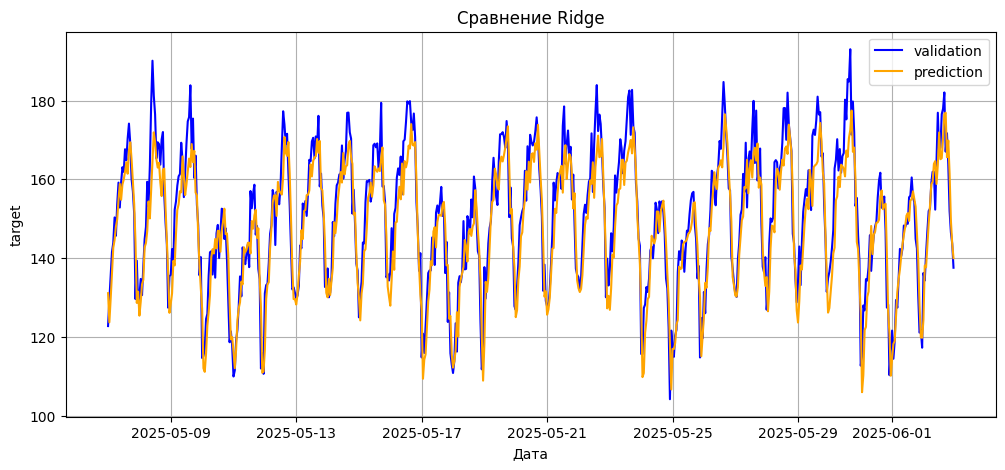

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(val_df['date'], val_df['target'], label='validation', color='blue')
plt.plot(val_df['date'], y_pred_val, label='prediction', color='orange')
plt.title('Сравнение Ridge')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, target, window_size, transform=None):
        self.data = data
        self.target = target
        self.window_size = window_size
        self.transform = transform

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.window_size]
        y_val = self.target[idx+self.window_size]
        if isinstance(y_val, np.ndarray):
            y_val = y_val.item()
        y = torch.FloatTensor([y_val])
        return torch.FloatTensor(x), y

def scale_target(train_target, val_target, test_target):
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_target.reshape(-1, 1))
    val_scaled   = scaler.transform(val_target.reshape(-1, 1))
    test_scaled  = scaler.transform(test_target.reshape(-1, 1))
    return train_scaled, val_scaled, test_scaled, scaler

train_target = train_feat['target'].values.reshape(-1,1)
val_target   = val_feat['target'].values.reshape(-1,1)
test_target  = test_feat['target'].values.reshape(-1,1)

train_target_scaled, val_target_scaled, test_target_scaled, scaler_target = scale_target(
    train_target, val_target, test_target
)

window_size = 10
train_dataset = TimeSeriesDataset(train_target_scaled, train_target_scaled, window_size)
val_dataset = TimeSeriesDataset(val_target_scaled, val_target_scaled, window_size)
test_dataset = TimeSeriesDataset(test_target_scaled, test_target_scaled, window_size)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [12]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        out = self.fc(out[:, -1, :])
        return out


In [13]:
model = GRUModel().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(x)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds = []
    all_true = []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            loss = criterion(pred, y)
            total_loss += loss.item() * x.size(0)
            all_preds.append(pred.cpu().numpy())
            all_true.append(y.cpu().numpy())
    all_preds = np.concatenate(all_preds)
    all_true = np.concatenate(all_true)
    # Обратное масштабирование
    all_preds = scaler_target.inverse_transform(all_preds)
    all_true = scaler_target.inverse_transform(all_true)
    mae, rmse, mape = compute_metrics(all_true, all_preds)
    return total_loss / len(loader.dataset), mae, rmse, mape

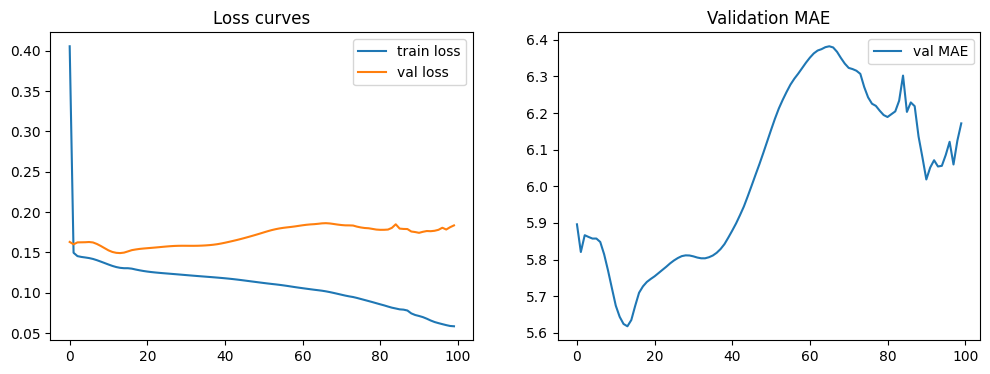

In [ ]:
from IPython import display
import matplotlib.pyplot as plt

epochs = 100
best_val_mae = float('inf')
history = {'train_loss': [], 'val_loss': [], 'val_mae': []}

plt.ion()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for epoch in range(epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_mae, val_rmse, val_mape = evaluate(model, val_loader, criterion)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_mae'].append(val_mae)

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), 'artifacts/best_gru.pt')
        config = {
            'window_size': window_size,
            'hidden_size': 64,
            'num_layers': 2,
            'lr': 0.001,
            'batch_size': batch_size,
            'seed': seed,
            'scaler_mean': scaler_target.mean_[0].item(),
            'scaler_scale': scaler_target.scale_[0].item(),
        }
        with open('artifacts/best_gru_config.json', 'w') as f:
            json.dump(config, f, indent=2)

    axes[0].clear()
    axes[0].plot(history['train_loss'], label='train loss')
    axes[0].plot(history['val_loss'], label='val loss')
    axes[0].legend()
    axes[0].set_title('Loss curves')

    axes[1].clear()
    axes[1].plot(history['val_mae'], label='val MAE')
    axes[1].legend()
    axes[1].set_title('Validation MAE')

    display.clear_output(wait=True)
    display.display(fig)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, val_MAE={val_mae:.4f}")

model.load_state_dict(torch.load('artifacts/best_gru.pt'))
final_val_loss, final_val_mae, final_val_rmse, final_val_mape = evaluate(model, val_loader, criterion)
print(f"Best GRU - Val: MAE={final_val_mae:.4f}, RMSE={final_val_rmse:.4f}, MAPE={final_val_mape:.4f}")

_, test_mae, test_rmse, test_mape = evaluate(model, test_loader, criterion)
print(f"Best GRU - Test: MAE={test_mae:.4f}, RMSE={test_rmse:.4f}, MAPE={test_mape:.4f}")

runs.append({
    'experiment_id': 'R1',
    'task': 'forecasting',
    'dataset': 'S12-hw-dataset',
    'seed': seed,
    'split_summary': 'train:70%, val:15%, test:15%',
    'window_size': window_size,
    'horizon': 1,
    'model_summary': 'GRU',
    'features_summary': 'target only',
    'scaler': 'StandardScaler (target)',
    'optimizer': 'Adam',
    'lr': 0.001,
    'epochs_trained': epochs,
    'best_val_mae': final_val_mae,
    'best_val_rmse': final_val_rmse,
    'best_val_mape': final_val_mape,
    'test_mae': test_mae,
    'test_rmse': test_rmse,
    'test_mape': test_mape,
    'notes': 'hidden_size=64, num_layers=2, batch_size=32'
})

plt.ioff()
display.clear_output(wait=True)  # очистить последний вывод
plt.savefig('artifacts/figures/gru_learning_curves.png')
plt.show()

In [15]:
runs_df = pd.DataFrame(runs)
runs_df.to_csv('artifacts/runs.csv', index=False)

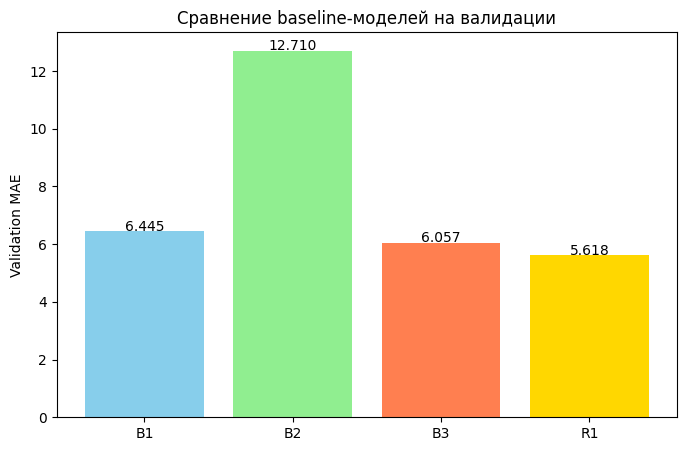

In [ ]:
val_mae = []
exp_ids = ['B1', 'B2', 'B3', 'R1']
for exp in runs:
    val_mae.append(exp['best_val_mae'])

plt.figure(figsize=(8,5))
plt.bar(exp_ids, val_mae, color=['skyblue', 'lightgreen', 'coral', 'gold'])
plt.ylabel('Validation MAE')
plt.title('Сравнение baseline-моделей на валидации')
for i, v in enumerate(val_mae):
    plt.text(i, v+0.01, f'{v:.3f}', ha='center')
plt.savefig('artifacts/figures/baselines_compare.png')
plt.show()

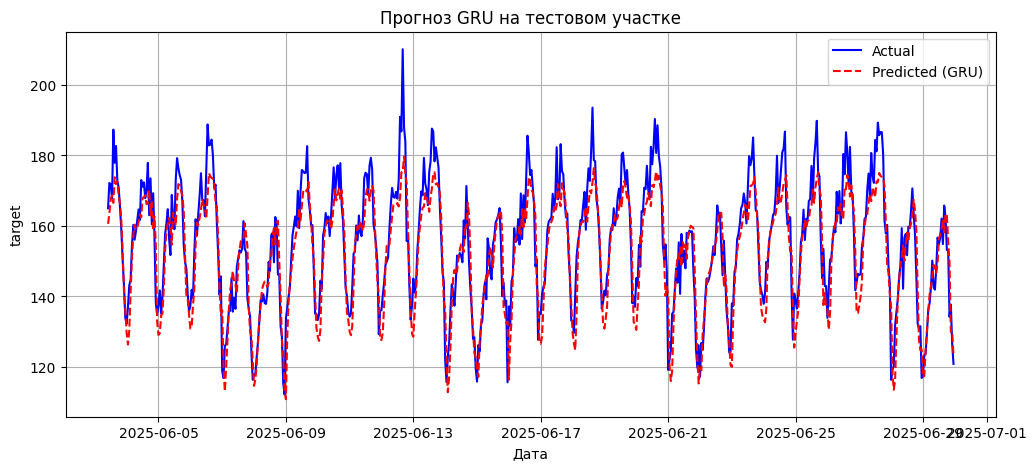

In [ ]:
model.eval()
all_preds = []
all_true = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        pred = model(x)
        all_preds.append(pred.cpu().numpy())
        all_true.append(y.numpy())
all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)
all_preds = scaler_target.inverse_transform(all_preds)
all_true = scaler_target.inverse_transform(all_true)


plt.figure(figsize=(12,5))
plt.plot(test_feat['date'].iloc[window_size:], all_true, label='Actual', color='blue')
plt.plot(test_feat['date'].iloc[window_size:], all_preds, label='Predicted (GRU)', color='red', linestyle='--')
plt.title('Прогноз GRU на тестовом участке')
plt.xlabel('Дата')
plt.ylabel('target')
plt.legend()
plt.grid(True)
plt.savefig('artifacts/figures/best_forecast_test.png')
plt.show()